<a href="https://colab.research.google.com/github/vaidiknakrani/parul_AI_ML_Learning/blob/main/Day_9_RAG_Langchain_OpenAI_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **How RAG works**

Image Source - (https://www.deeplearning.ai/)


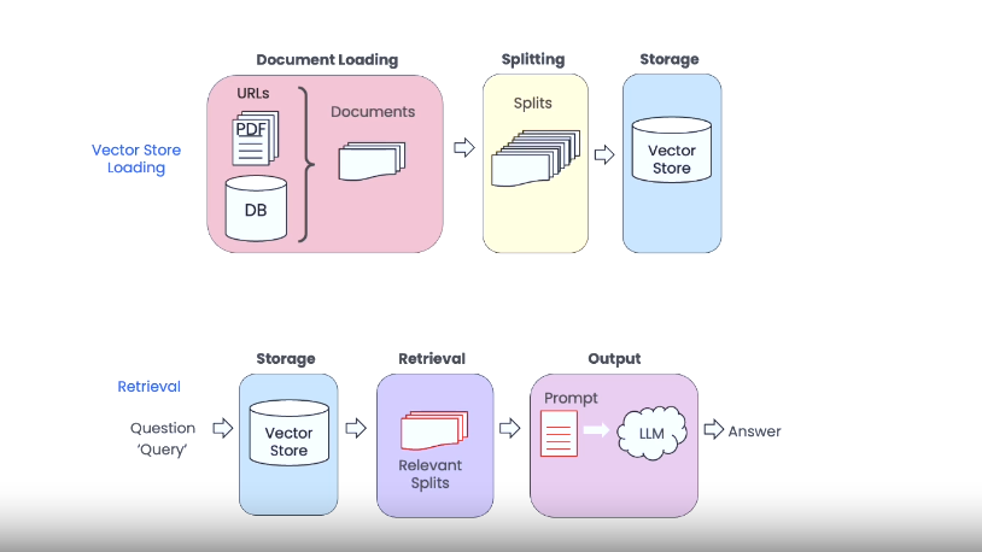

## PDF Query Using Langchain

In [1]:
!pip install langchain
!pip install openai
!pip install PyPDF2
!pip install faiss-cpu
!pip install tiktoken
!pip install langchain_community
#!pip install langchain-openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
!pip install -U langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 14.1 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9


In [10]:
from PyPDF2 import PdfReader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

# Removed: from langchain.chains.question_answering import load_qa_chain
from langchain_openai import OpenAI



```
# This is formatted as code
```



In [25]:
import os
from google.colab import userdata

openai_key = userdata.get('OPEN_API_KEY')

if openai_key:
    # Strip any leading/trailing whitespace, including newlines, from the key
    os.environ["OPENAI_API_KEY"] = openai_key.strip()
    print(f"OpenAI API Key successfully retrieved and set. (Starts with: {os.environ["OPENAI_API_KEY"][:5]}...)")
elif 'OPEN_API_KEY' in os.environ:
    print("OPEN_API_KEY was already set in environment.")
else:
    print("Warning: OPEN_API_KEY not found in Colab secrets. Please ensure it's added.")


OpenAI API Key successfully retrieved and set. (Starts with: sk-pr...)


In [14]:
# provide the path of  pdf file/files.
pdfreader = PdfReader('llm6g.pdf')

In [15]:
from typing_extensions import Concatenate
# read text from pdf
raw_text = ''
for i, page in enumerate(pdfreader.pages):
    content = page.extract_text()
    if content:
        raw_text += content


In [16]:
raw_text

'AI/ML Capstone Project Problem Statements Parul University & TelcoLearn — 2027 Batch\nAI/ML Capstone Project Problem Statements\nParul University in collaboration with TelcoLearn\nB.Tech 3rd/4th Year — 2027 Graduating Batch — Phase 2 Bootcamp\nArpit Tripathi & Sanjay Kumar\nInstructions for Students\nTeam composition: Each project is designed for a team of four students. Every sub-problem\n(Student A through D) is a self-contained contribution that one team member owns end-to-end,\nwhile the team integrates the parts into a single deployed application.\nFull-stack requirement: Every project must be delivered as a running web application or\nmobile application. The deployment component is mandatory, not optional. Recommended\nstacks:\n\x88Web: FastAPI or Flask (backend) + React or Streamlit (frontend), deployed on Render,\nRailway, or HuggingFace Spaces (free tier).\n\x88Mobile: Flutter or React Native frontend calling a FastAPI backend; model served via\nONNX Runtime or TFLite for on-

In [17]:
# We need to split the text using Character Text Split such that it sshould not increse token size
text_splitter = CharacterTextSplitter(
    separator = "\n",
    chunk_size = 800,
    chunk_overlap  = 200,
    length_function = len,
)
texts = text_splitter.split_text(raw_text)

In [18]:
len(texts)

106

In [19]:
# Download embeddings from OpenAI
embeddings = OpenAIEmbeddings()

In [28]:
document_search = FAISS.from_texts(texts, embeddings)

APIConnectionError: Connection error.

Let's test the OpenAI API key by generating a simple embedding directly.

In [21]:
import openai

# Assuming OPEN_API_KEY is already set in os.environ
try:
    # Attempt to create a simple embedding
    response = openai.embeddings.create(
        input="This is a test sentence.",
        model="text-embedding-ada-002"
    )
    print("API Key test successful! Embedding generated.")
    # Optionally, print a part of the embedding to confirm
    # print(response.data[0].embedding[:5])
except openai.APIConnectionError as e:
    print(f"API Connection Error during test: {e}")
    print("Please check your internet connection, OpenAI's status page (status.openai.com), or try again later.")
except openai.AuthenticationError as e:
    print(f"API Authentication Error during test: {e}")
    print("Your API key might be invalid, expired, or revoked. Please double-check it in Colab secrets and on the OpenAI platform.")
except openai.APITimeoutError as e:
    print(f"API Timeout Error during test: {e}")
    print("The request timed out. This might be due to network latency or high server load.")
except Exception as e:
    print(f"An unexpected error occurred during API test: {e}")

API Connection Error during test: Connection error.
Please check your internet connection, OpenAI's status page (status.openai.com), or try again later.


In [22]:
import os

# Verify if the OPEN_API_KEY is set in the environment variables
api_key_status = "OPEN_API_KEY is set." if os.environ.get('OPEN_API_KEY') else "OPEN_API_KEY is NOT set."
print(f"API Key Status: {api_key_status}")

# To print the key itself for debugging (be cautious with sensitive info in output)
# print(f"OpenAI API Key (first 5 chars): {os.environ.get('OPEN_API_KEY')[:5]}...")

API Key Status: OPEN_API_KEY is NOT set.


In [27]:
document_search


NameError: name 'document_search' is not defined

In [ ]:
chain = load_qa_chain(OpenAI(), chain_type="stuff")

<ipython-input-13-25e042d5cc81>:1: LangChainDeprecationWarning: The class `OpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAI``.
  chain = load_qa_chain(OpenAI(), chain_type="stuff")
<ipython-input-13-25e042d5cc81>:1: LangChainDeprecationWarning: This class is deprecated. See the following migration guides for replacements based on `chain_type`:
stuff: https://python.langchain.com/docs/versions/migrating_chains/stuff_docs_chain
map_reduce: https://python.langchain.com/docs/versions/migrating_chains/map_reduce_chain
refine: https://python.langchain.com/docs/versions/migrating_chains/refine_chain
map_rerank: https://python.langchain.com/docs/versions/migrating_chains/map_rerank_docs_chain

See also guides on retrieval and question-answering here: 

In [ ]:
query = "What is the use of LLM in 6G Networks?"
docs = document_search.similarity_search(query)
chain.run(input_documents=docs, question=query)

' The use of LLM in 6G Networks is to enhance personalized healthcare, streamline logistics, transform education, and potentially unlock entirely new applications and functionalities that we can’t even imagine today. LLMs can also be integrated into 6G network elements to enhance software enhancements and ensure a continuous seamless integration of diverse applications and services.'

In [ ]:
query = "Who is the prime minister of India"
docs = document_search.similarity_search(query)
chain.run(input_documents=docs, question=query)

" I don't know."

In [ ]:

query = "Who is the CM of Delhi"
docs = document_search.similarity_search(query)
chain.run(input_documents=docs, question=query)

" I don't know. This information is not provided in the given context. "

In [ ]:
query = "What is Open RAN"
docs = document_search.similarity_search(query)
chain.run(input_documents=docs, question=query)


' Open RAN is a concept that aims to revolutionize the Radio Access Network (RAN) by promoting open standards and architectures. It involves using open interfaces, disaggregated network components, and AI-driven intelligence and automation to create a more innovative, interoperable, and cost-effective wireless network ecosystem. Open RAN also involves the use of two Radio Intelligent Controller (RIC) designs - Non-real-time and Near-real-time - for managing operations and facilitating AI/ML training. There is no specific technology prescribed for Open RAN, but it must meet certain standards for efficient routing and data protection. The emerging research in AI RAN further emphasizes the integration of AI/ML capabilities directly within the RAN to enhance operational efficiency and support new use cases.'

In [ ]:
query = "is AI ML Important for 6G"
docs = document_search.similarity_search(query)
chain.run(input_documents=docs, question=query)

' Yes, AI and Machine Learning (ML) are important for 6G as they can significantly enhance the capabilities and performance of the network, enabling new applications and driving innovation. However, there are also technical challenges that need to be addressed to ensure seamless integration and efficient operation of AI and ML within the 6G ecosystem. '

In [ ]:
query = "is AI ML important for 2G?"
docs = document_search.similarity_search(query)
chain.run(input_documents=docs, question=query)

' No, the context provided only mentions AI ML in relation to 6G networks. There is no mention of 2G networks.'

In [29]:
query = "is 5G a successful Technology?"
docs = document_search.similarity_search(query)
chain.run(input_documents=docs, question=query)

NameError: name 'document_search' is not defined

In [ ]:
query = "Who is Markus Abel?"
docs = document_search.similarity_search(query)
chain.run(input_documents=docs, question=query)

" I don't know."